**1.Import the Pandas, Numpy and Matplotlib libraries**

In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df =pd.read_csv("/content/covid19.csv")

**2.Read the Covid19 dataset from your sample_data folder into a Pandas dataframe**

In [381]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            453 non-null    object 
 1   first_dose      445 non-null    float64
 2   second_dose     445 non-null    float64
 3   icu             453 non-null    int64  
 4   hospital        453 non-null    int64  
 5   positive_tests  75 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 21.4+ KB
None
         first_dose   second_dose         icu     hospital  positive_tests
count  4.450000e+02  4.450000e+02  453.000000   453.000000       75.000000
mean   3.480783e+06  2.690738e+06   46.675497   832.551876      192.680000
std    1.193378e+06  1.561651e+06   34.644698   617.199739       82.239459
min    1.633770e+05  2.758000e+03    2.000000    58.000000       78.000000
25%    2.817752e+06  1.297664e+06   20.000000   341.000000      134.500000
50%    4.075555e+0

**3.Using Pandas clean the dataset by removing missing data**

In [382]:
# we can see our data has a few object columns
# the data must be all numeric to do correlation
# hence setting numeric_only=true will ignore everything except numbers
print(df.isnull().sum())
df= df.dropna()# remove rows with missing values
print(df.info())




date                0
first_dose          8
second_dose         8
icu                 0
hospital            0
positive_tests    378
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 74 entries, 366 to 452
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            74 non-null     object 
 1   first_dose      74 non-null     float64
 2   second_dose     74 non-null     float64
 3   icu             74 non-null     int64  
 4   hospital        74 non-null     int64  
 5   positive_tests  74 non-null     float64
dtypes: float64(3), int64(2), object(1)
memory usage: 4.0+ KB
None


*intially there were 453 entries after cleaning dropped down to 76 entries*

**4.Explore the dataset both statistically and visually looking for useful correlations between 'icu' and other features**

In [383]:
# looking for correlation between ICU and other features
df.corr(numeric_only=True)


,first_dose,second_dose,icu,hospital,positive_tests
first_dose,1.000000,0.814617,-0.211171,-0.716471,-0.230490
second_dose,0.814617,1.000000,-0.623253,-0.438264,-0.656142
icu,-0.211171,-0.623253,1.000000,0.201573,0.954329
hospital,-0.716471,-0.438264,0.201573,1.000000,0.131880
positive_tests,-0.230490,-0.656142,0.954329,0.131880,1.000000


**correlation between ICU and Positive tests**

In [384]:
x=df['icu'].to_numpy() # set the x value as icu
y=df['positive_tests'].to_numpy()# set the y value as positive tests

Text(0, 0.5, 'Positive tests')

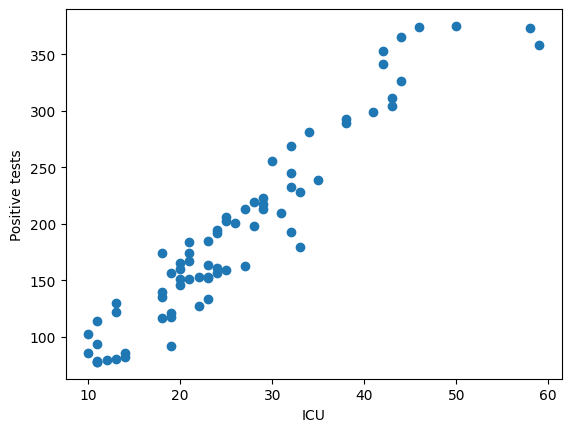

In [385]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.xlabel("ICU")
plt.ylabel("Positive tests")

**correlation between ICU and hospital**

In [386]:
x=df['icu'].to_numpy()
y = df['hospital'].to_numpy()

Text(0, 0.5, 'HOSPITAL')

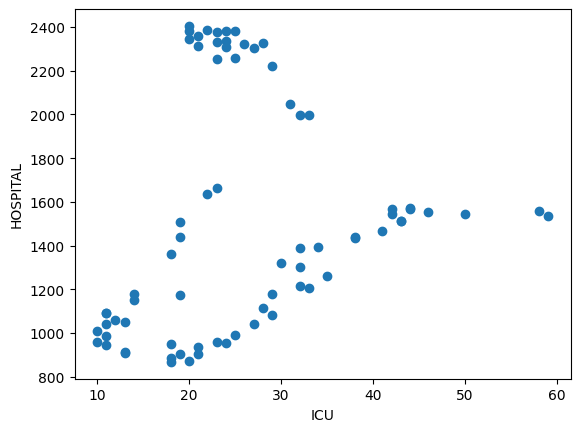

In [387]:
import matplotlib.pyplot as plt
plt.scatter(x,y) # choose chart type for the x and y values to plot
plt.xlabel("ICU") # display a label for x
plt.ylabel("HOSPITAL") # display a label for y

**correlation between ICU and First dose**

In [388]:
x=df['icu'].to_numpy()
y=df['first_dose'].to_numpy()


Text(0, 0.5, 'First Dose')

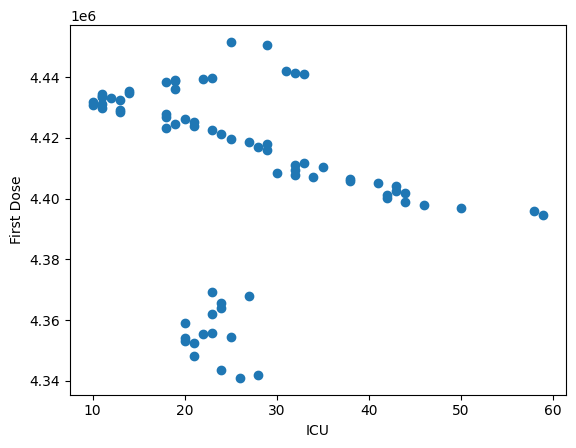

In [389]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.xlabel("ICU")
plt.ylabel("First Dose")

**correlation between ICU and Second dose**

In [390]:
x=df['icu'].to_numpy()
y=df['second_dose'].to_numpy()

Text(0, 0.5, 'Second Dose')

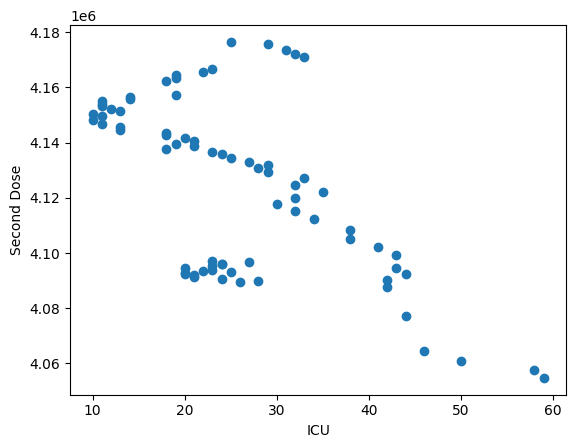

In [391]:
import matplotlib.pyplot as plt
plt.scatter(x,y)
plt.xlabel("ICU")
plt.ylabel("Second Dose")

**5.Analyse your findings**

In [392]:
# Positive cases correlated more with ICU (0.954329)
# icu cases dropped compared to hospital visits as people have become more resistant to the virus by building immunity (and also the herd immunity concept)and building up pre-formed antibodies. one more reason could be after two doses of immunisations, people have developed antibodies required to fight the infection.

**6. Explain the term data bias and identify an any potential bias in this dataset**

In [393]:
#  data bias refers to systematic errors that lead to incorrect or unfair conclusions. These errors can be caused by how data is collected, selected, or represented.
# potential data bias in this data set seems be sample bias(potentially of missing values, initially 453 entries were there but dropped down to 74, this means only a small subset of data is used.
# selection bias as it is not representative of complete data
# missing data bias as lot of nulls occured

**7. prepare datasets for a machine learning model. Create a numpy array called 'x' for the identified feature and one called 'y' for 'icu'.**

In [404]:
x=df[['positive_tests']].to_numpy()
y=df[['icu']].to_numpy()
# we change to numpy as it is a faster and more efficient tool for data manipulation



**8.Split these x and y numpy arrays into training and testing sets. Use a 90%/10% split.**

In [ ]:
ninty_percent=int(np.shape(x)[0]*0.9)
# calculate 90% of the data
x_train = x[:ninty_percent]
y_train=y[:ninty_percent]
#set the training data
x_test=x[ninty_percent:]
y_test=y[ninty_percent:]

**9.Creating the model, fit linear regression model**

In [395]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# set the model to be used as linear regression
# train the linear regression model
model.fit(x_train, y_train)


LinearRegression()

**10.Use the LinearRegression model's score() method to statistically measure the performance on both the training and testing sets**

In [396]:

# display the scores for training and testing (higher is better)
lr_score_train = model.score(x_train, y_train)
print(lr_score_train)
lr_score_test = model.score(x_test, y_test)
print(lr_score_test)

0.9149349606977394
-0.8715046973351988


**11.Predict and Visualise Results**

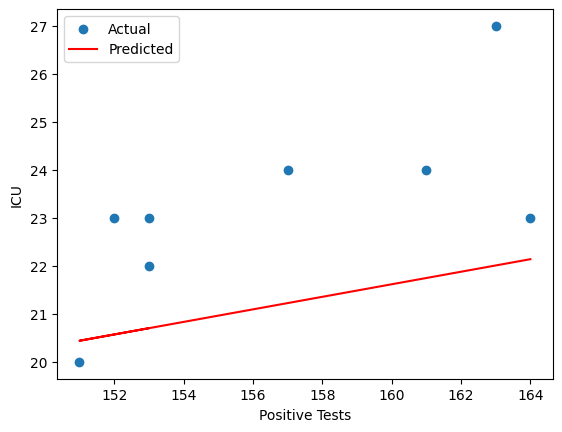

In [397]:
# test the model
y_pred=model.predict(x_test)

import matplotlib.pyplot as plt
plt.scatter(x_test, y_test, label='Actual')
plt.plot(x_test, y_pred, color='red', label='Predicted')
plt.xlabel("Positive Tests")
plt.ylabel("ICU")
plt.legend()
plt.show()


****12.Use all the features to prepare datasets for a more powerful machine learning model. Create a numpy multi-dimensional array called 'x' for the all the features and again one called 'y' for 'icu'.**

**Random Forest Regressor model **

In [398]:
# set x and y values
x=df[['positive_tests','first_dose','second_dose','hospital']].to_numpy()
y=df['icu'].to_numpy()

**13.Split these x and y numpy arrays into training and testing sets. Use a 90%/10% split again.**

In [399]:
ninty_percent=int(len(df)*0.9)
x_train=x[:ninty_percent]
y_train=y[:ninty_percent]
x_test= x[ninty_percent:]
y_test =y[ninty_percent:]

**14.Fit the powerful RandomForestRegressor model from SKLearn to the above training set**

In [400]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)# create the model and set the amount of entries to use
model.fit(x_train,y_train)

RandomForestRegressor()

**15.Use the RandomForestRegressor model's score() method to statistically measure the performance on both the training and testing sets**

In [401]:
rf_train_score = model.score(x_train, y_train)
rf_test_score = model.score(x_test, y_test)# test the model
print("Train score:", rf_train_score)
print("Test score:", rf_test_score)
 # display the score

Train score: 0.9918303928422569
Test score: -1.5365818181818187


**16.Use the RandomForestRegressor model's predict() method and matplotlib to visualise the performance on both the training and testing sets**

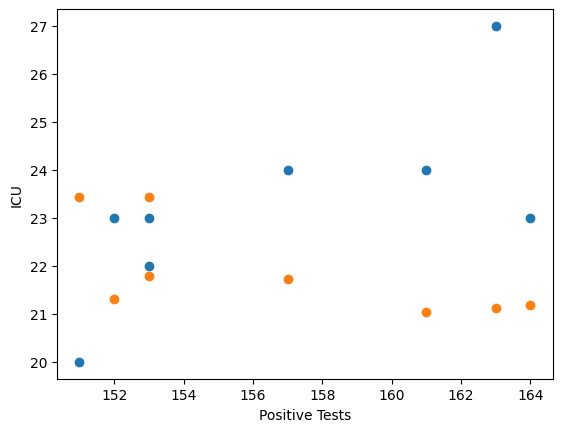

In [402]:
y_test_pred = model.predict(x_test) # predict the model
plt.scatter(x_test[:,0],y_test, label='Actual')# plot the training data- Access the 'posituve tests' column using indexing
plt.scatter(x_test[:,0],y_test_pred, label ='predicted')
plt.xlabel("Positive Tests")
plt.ylabel("ICU")
plt.show()

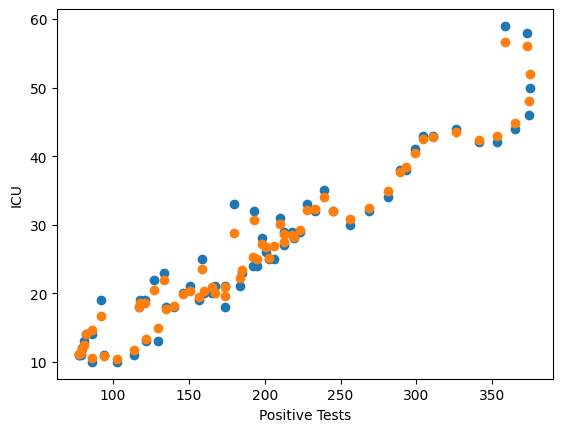

In [403]:
y_train_predT=model.predict(x_train)# predict the model
plt.scatter(x_train[:,0],y_train, label='Actual')#plot the training data-access the 'positive tests' column using indexing
plt.scatter(x_train[:,0],y_train_predT, label='Predicted')# plot the predicted data- acces the 'positve tests' column using indexing
plt.xlabel("Positive Tests")
plt.ylabel("ICU")
plt.show()

**17.Explain the results from the Linear Regression and Random Forest models.**

*Linear Regression*
# Training Score: 0.91
Good fit on training data, 91% of the variance in ICU numbers.
#Test Score: -0.87
 Negative score indicates very poor performance. This is considered a low score, indicating that the model is not performing well and may not be a good fit for the data.

*Random Forest*
#Training Score: 0.99
Excellent fit on training data but suggest overfitting.

#Test Score: -1.66
 This is considered a low score, indicating that the model is not performing well and may not be a good fit for the data.


**Which had the best the performance on the training set?**

Random Forest had the best performance with a training score of 0.99 but this might be overfitting without generalising well

**Which had the best performance on the test set?**
linear regression has the better score of -0.87 compared to random forest whoch is -1.66 ... however both the scores are bad as negeative values indicate they are not generalising the data well

**Which model would you use for making 'icu' predictions?**

both the models fail to generalise because of negative test scores but comparatively, I would choose linear regression as it is less likely to overfit and better generalisation.

**How come?**
Random Forest is overfitting it memorizes training data (high train score) but fails on test data(very negative score).

Linear Regression overfits less, but still fails because: Relationships may not be straight,
Important features missing,
and There could be bias in the data.

**How could you improve the predictions of the other model?**



To improve Random Forest:
Reduce overfitting by Limiting tree depth (max_depth),
Reduce number of trees (n_estimators),
Use cross-validation to evaluate generalization performance more reliably.. By averaging the results of many trees, random forests are less likely to overfit.



Feature engineering is crucial for improving model performance by removing irrelevant/highly correlated/incomplete features by Cleaning & Transforming Data Types,
Ensuring that all variables are in the correct format, input missing values.



  